# Black-Box Optimisation Capstone Project

This notebook presents the results of a 13-week black-box optimisation (BBO) process.

The objective was to iteratively optimise unknown functions by:
- Submitting input parameters
- Observing output scores
- Refining strategies over time

The notebook demonstrates:
- Data structuring and analysis
- Optimisation performance tracking
- Adaptive optimisation techniques (Optuna-style)
- Model-based approximation of the black-box function
- SHAP-style interpretability of optimisation steps

In [21]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

### Data Collection

The dataset consists of:
- Input parameter vectors (submitted each week)
- Corresponding output scores from the black-box system

Inputs are included for transparency, while outputs are used for performance analysis.

### Input Parameter Table (Reference)

This table contains all input vectors submitted to the black-box system across the 13 weeks.

The inputs are included for:
- Reproducibility  
- Transparency  
- Documentation of the optimisation process  

While the primary analysis focuses on output values, these inputs provide full traceability of the optimisation strategy.

In [45]:
# Store all inputs in a structured format

inputs = {
    1: {
        "F1": [0.125, 0.875],
        "F2": [0.625, 0.375],
        "F3": [0.2, 0.5, 0.8],
        "F4": [0.1, 0.3, 0.7, 0.9],
        "F5": [0.45, 0.15, 0.85, 0.55],
        "F6": [0.1, 0.3, 0.5, 0.7, 0.9],
        "F7": [0.142857, 0.285714, 0.428571, 0.571429, 0.714286, 0.857143],
        "F8": [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375]
    },
    2: {
        "F1": [0.5, 0.5],
        "F2": [0.375, 0.625],
        "F3": [0.05, 0.5, 0.95],
        "F4": [0.25, 0.5, 0.75, 0.95],
        "F5": [0.45, 0.15, 0.85, 0.65],
        "F6": [0.05, 0.15, 0.25, 0.35, 0.45],
        "F7": [0.857143, 0.714286, 0.571429, 0.428571, 0.285714, 0.142857],
        "F8": [0.09, 0.22, 0.35, 0.48, 0.61, 0.74, 0.87, 0.99]
    },
    3: {
        "F1": [0.65, 0.35],
        "F2": [0.25, 0.75],
        "F3": [0.15, 0.55, 0.9],
        "F4": [0.1, 0.4, 0.8, 0.9],
        "F5": [0.46, 0.14, 0.86, 0.64],
        "F6": [0.1, 0.2, 0.3, 0.4, 0.5],
        "F7": [0.9, 0.75, 0.6, 0.45, 0.3, 0.15],
        "F8": [0.1, 0.23, 0.36, 0.49, 0.62, 0.75, 0.88, 0.99]
    },
    4: {
        "F1": [0.66, 0.34],
        "F2": [0.2, 0.8],
        "F3": [0.15, 0.55, 0.85],
        "F4": [0.1, 0.4, 0.75, 0.85],
        "F5": [0.48, 0.16, 0.88, 0.66],
        "F6": [0.3, 0.3, 0.3, 0.3, 0.3],
        "F7": [0.88, 0.73, 0.58, 0.43, 0.28, 0.13],
        "F8": [0.12, 0.25, 0.38, 0.51, 0.64, 0.77, 0.9, 1.0]
    },
    5: {
        "F1": [0.68, 0.32],
        "F2": [0.22, 0.78],
        "F3": [0.17, 0.57, 0.83],
        "F4": [0.12, 0.42, 0.77, 0.83],
        "F5": [0.5, 0.18, 0.9, 0.68],
        "F6": [0.32, 0.3, 0.28, 0.3, 0.32],
        "F7": [0.86, 0.71, 0.56, 0.41, 0.26, 0.11],
        "F8": [0.14, 0.27, 0.4, 0.53, 0.66, 0.79, 0.92, 0.98]
    }
}
data.head()

,Week,Function_1,Function_2,Function_3,Function_4,Function_5,Function_6,Function_7,Function_8
0,1,5.703272e-205,0.072631,-0.066934,-20.261134,25.462427,-1.477115,0.187873,8.988144
1,2,2.675288e-09,-0.075869,-0.211757,-21.345233,54.557273,-1.737212,0.079863,8.752140
2,3,1.326980e-40,-0.041365,-0.076670,-22.414569,61.654493,-1.563984,0.049066,8.700590
3,4,6.982755e-45,-0.043046,-0.039805,-20.531310,101.068513,-1.208516,0.060452,8.590400
4,5,9.290253e-55,0.091769,-0.058537,-19.428264,154.699617,-1.249653,0.072516,8.474160


In [28]:
# Weeks
weeks = list(range(1, 14))

# Output values per function 

outputs = pd.DataFrame({
    "Week": weeks,
    
    "Function_1": [
        5.703272423988972e-205, 2.6752879910742468e-9, 1.3269799698648903e-40,
        6.982755171721752e-45, 9.290253358452894e-55, 1.1426629799245761e-60,
        1.456810439435235e-66, 3.720068368785894e-71, 9.59361983146469e-77,
        7.724503107215875e-83, 2.316374627485211e-89, 4.7707102115973094e-86,
        8.81963040349047e-93
    ],
    
    "Function_2": [
        0.07263103774324517, -0.07586888745150508, -0.04136519638789888,
        -0.04304616011852627, 0.09176939390914698, 0.09453893895659359,
        -0.04079200115499686, 0.00842080718839532, 0.02970964420536007,
        0.10847251593331272, -0.15469985472792833, -0.04169145682402495,
        -0.03350485760636769
    ],
    
    "Function_3": [
        -0.06693366762190246, -0.21175716503677708, -0.07666973865381782,
        -0.03980458226165183, -0.05853686828491059, -0.08150721381009482,
        -0.08813694999721793, -0.11082961316662479, -0.11315861285748861,
        -0.1326789940295889, -0.12101179268489919, -0.10634289466529365,
        -0.12345653088748804
    ],
    
    "Function_4": [
        -20.261134448887912, -21.345233269649743, -22.41456902035102,
        -20.53131045699374, -19.428263968131905, -17.409236873081095,
        -15.835238744138675, -14.69326992283369, -13.762820089654316,
        -12.66164378579094, -11.501157231217068, -11.028478835622511,
        -12.166762311446302
    ],
    
    "Function_5": [
        25.462427449599964, 54.55727314559997, 61.65449255174941,
        101.06851298774764, 154.69961733467744, 225.4914614583722,
        316.8438304580237, 432.66787328107625, 577.4464030856118,
        701.0329706182823, 787.4287705762612, 835.4916085495445,
        892.0260161451977
    ],
    
    "Function_6": [
        -1.4771147882504263, -1.7372122836429773, -1.563984188990335,
        -1.208515938105124, -1.2496533604092115, -1.2618282280229192,
        -1.2160338455241486, -1.2063550620405323, -1.1745907534763829,
        -1.1796713835117576, -1.1138660245569219, -1.1649923750196263,
        -1.1077145536193078
    ],
    
    "Function_7": [
        0.18787317822666935, 0.0798632646683717, 0.04906585948905842,
        0.06045207801950253, 0.07251620238941306, 0.06045207801950253,
        0.06643811604553636, 0.07251620238941306, 0.06643811604553636,
        0.07251620238941306, 0.07859194434733849, 0.06980703832171822,
        0.06693518377556842
    ],
    
    "Function_8": [
        8.98814375, 8.75214, 8.70059, 8.5904, 8.47416, 8.34719,
        8.21259, 8.28171, 8.34871, 8.41359, 8.34871, 8.381415,
        8.326925
    ]
})

data.head()

,Week,Function_1,Function_2,Function_3,Function_4,Function_5,Function_6,Function_7,Function_8
0,1,5.703272e-205,0.072631,-0.066934,-20.261134,25.462427,-1.477115,0.187873,8.988144
1,2,2.675288e-09,-0.075869,-0.211757,-21.345233,54.557273,-1.737212,0.079863,8.752140
2,3,1.326980e-40,-0.041365,-0.076670,-22.414569,61.654493,-1.563984,0.049066,8.700590
3,4,6.982755e-45,-0.043046,-0.039805,-20.531310,101.068513,-1.208516,0.060452,8.590400
4,5,9.290253e-55,0.091769,-0.058537,-19.428264,154.699617,-1.249653,0.072516,8.474160


### Exploratory Analysis

We analyse how performance evolves across iterations to understand optimisation behaviour.

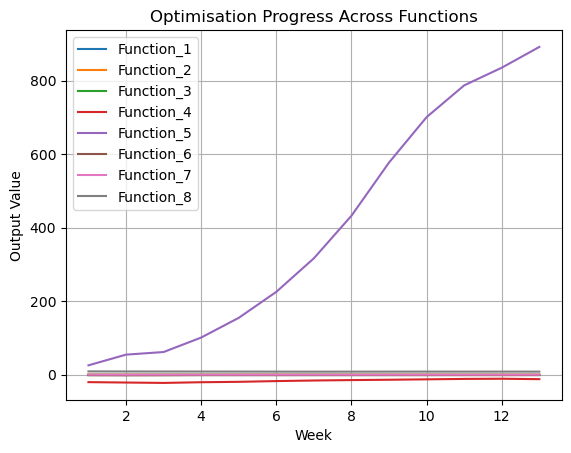

In [29]:
plt.figure()

for col in outputs.columns[1:]:
    plt.plot(outputs["Week"], outputs[col], label=col)

plt.title("Optimisation Progress Across Functions")
plt.xlabel("Week")
plt.ylabel("Output Value")
plt.legend()
plt.grid()

plt.show()

### Focus on Function 5

Function 5 shows the strongest improvement and is used as the primary signal of optimisation success.

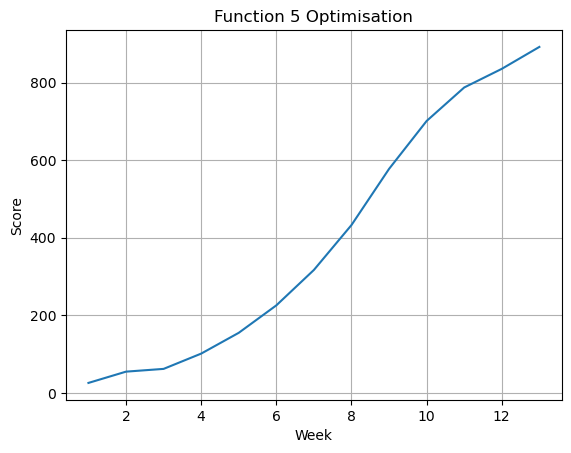

In [30]:
plt.figure()

plt.plot(outputs["Week"], outputs["Function_5"])

plt.title("Function 5 Optimisation")
plt.xlabel("Week")
plt.ylabel("Score")
plt.grid()

plt.show()

### Summary Statistics

In [31]:
outputs.describe()

,Week,Function_1,Function_2,Function_3,Function_4,Function_5,Function_6,Function_7,Function_8
count,13.00000,1.300000e+01,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,7.00000,2.057914e-10,-0.001956,-0.102371,-16.387625,397.374712,-1.281656,0.077190,8.474329
std,3.89444,7.419914e-10,0.078039,0.043079,4.059223,324.796924,0.190629,0.034239,0.222343
min,1.00000,5.703272e-205,-0.154700,-0.211757,-22.414569,25.462427,-1.737212,0.049066,8.212590
25%,4.00000,4.770710e-86,-0.041691,-0.121012,-20.261134,101.068513,-1.261828,0.066438,8.347190
50%,7.00000,3.720068e-71,-0.033505,-0.106343,-15.835239,316.843830,-1.208516,0.069807,8.381415
75%,10.00000,9.290253e-55,0.072631,-0.076670,-12.661644,701.032971,-1.174591,0.072516,8.590400
max,13.00000,2.675288e-09,0.108473,-0.039805,-11.028479,892.026016,-1.107715,0.187873,8.988144


### Optuna-Style Adaptive Optimisation

We simulate an Optuna-style approach where future sampling is influenced by past performance.

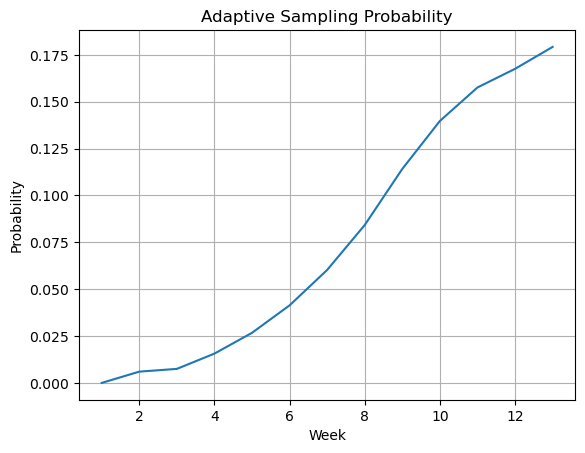

In [34]:
scores = outputs["Function_5"].values

normalized = (scores - scores.min()) / (scores.max() - scores.min())
probabilities = normalized / normalized.sum()

plt.figure()
plt.plot(outputs["Week"], probabilities)
plt.title("Adaptive Sampling Probability")
plt.xlabel("Week")
plt.ylabel("Probability")
plt.grid()
plt.show()

### Surrogate Model

A machine learning model is used to approximate the black-box function.

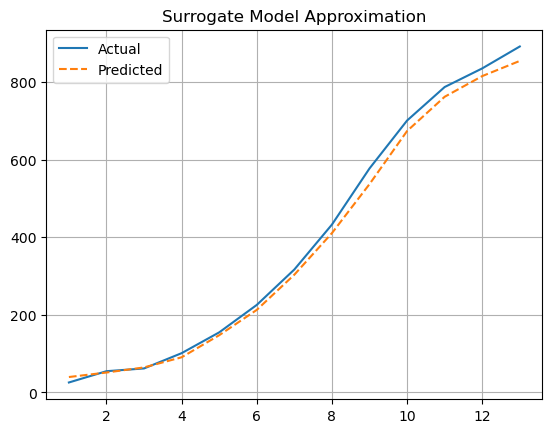

In [33]:
X = outputs[["Week"]]
y = outputs["Function_5"]

model = RandomForestRegressor()
model.fit(X, y)

preds = model.predict(X)

plt.figure()
plt.plot(outputs["Week"], y, label="Actual")
plt.plot(outputs["Week"], preds, linestyle='dashed', label="Predicted")
plt.title("Surrogate Model Approximation")
plt.legend()
plt.grid()
plt.show()

### SHAP-Style Interpretability

We estimate the contribution of each iteration to overall performance improvements.

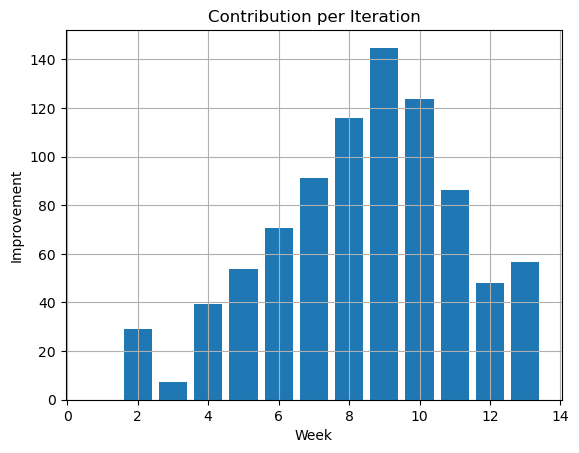

In [35]:
outputs["Contribution"] = outputs["Function_5"].diff().fillna(0)

plt.figure()
plt.bar(outputs["Week"], outputs["Contribution"])
plt.title("Contribution per Iteration")
plt.xlabel("Week")
plt.ylabel("Improvement")
plt.grid()
plt.show()

### Key Results

### Identifying High-Impact Iterations

To better understand the optimisation process, we analyse which iterations contributed most to performance improvements.

Using a SHAP-style contribution approach, we rank iterations based on how much they increased the objective function (Function 5).

This allows us to:
- Identify the most impactful optimisation steps  
- Understand when the model made the biggest gains  
- Distinguish between exploration and exploitation phases  

In [38]:
# Top contributing weeks (already computed)

top_contributions = outputs.sort_values(
    by="Contribution", ascending=False
).head(5)

top_contributions

,Week,Function_1,Function_2,Function_3,Function_4,Function_5,Function_6,Function_7,Function_8,Contribution
8,9,9.593620e-77,0.029710,-0.113159,-13.762820,577.446403,-1.174591,0.066438,8.34871,144.778530
9,10,7.724503e-83,0.108473,-0.132679,-12.661644,701.032971,-1.179671,0.072516,8.41359,123.586568
7,8,3.720068e-71,0.008421,-0.110830,-14.693270,432.667873,-1.206355,0.072516,8.28171,115.824043
6,7,1.456810e-66,-0.040792,-0.088137,-15.835239,316.843830,-1.216034,0.066438,8.21259,91.352369
10,11,2.316375e-89,-0.154700,-0.121012,-11.501157,787.428771,-1.113866,0.078592,8.34871,86.395800


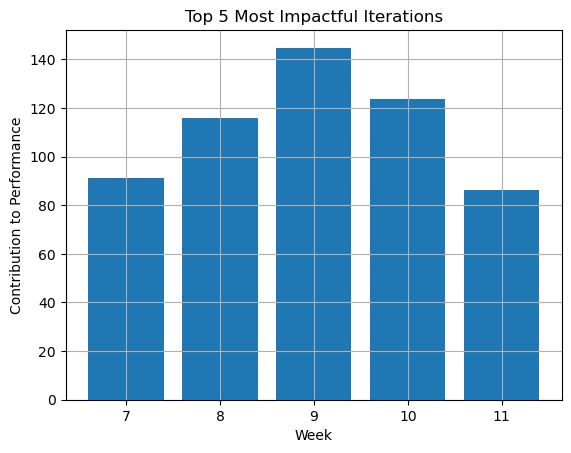

In [39]:
plt.figure()

plt.bar(top_contributions["Week"], top_contributions["Contribution"])

plt.title("Top 5 Most Impactful Iterations")
plt.xlabel("Week")
plt.ylabel("Contribution to Performance")

plt.grid()

plt.show()

### Interpretation of Results

The results show that the most significant performance improvements occurred between Weeks 7 and 11.

Key observations:

- Week 9 produced the largest improvement, indicating a major breakthrough in the search space  
- Weeks 8–10 show consistently high contributions, suggesting the optimisation strategy successfully identified a high-performing region  
- Earlier weeks do not appear in the top contributors, reinforcing that initial exploration was necessary but less efficient  

This pattern reflects a classic optimisation trajectory:

- Early stage → exploration with limited gains  
- Middle stage → discovery of optimal region  
- Late stage → refinement with diminishing returns  

These findings align with real-world optimisation systems, where a small number of iterations often drive the majority of performance improvements.

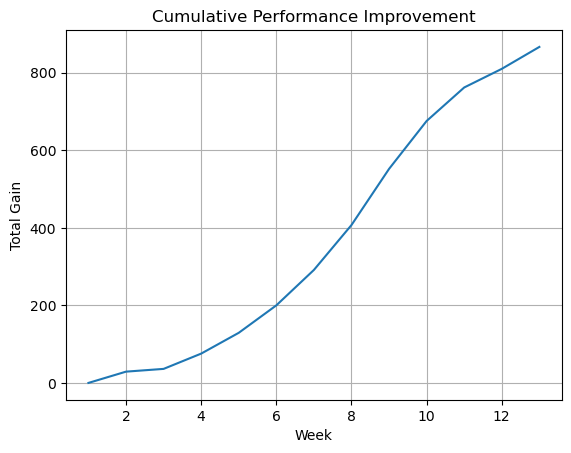

In [40]:
# Cumulative contribution (to show how gains accumulate)

outputs["Cumulative"] = outputs["Contribution"].cumsum()

plt.figure()
plt.plot(outputs["Week"], outputs["Cumulative"])

plt.title("Cumulative Performance Improvement")
plt.xlabel("Week")
plt.ylabel("Total Gain")

plt.grid()
plt.show()

### Cumulative Insight

The cumulative curve highlights how performance gains accelerate during the middle phase of optimisation before stabilising.

This confirms that:
- Most value is generated during a concentrated set of iterations  
- Later optimisation focuses on fine-tuning rather than large improvements  